# Notebook 04: Dashboard Analysis & Procurement Planning

**Purpose**: Generate KPIs, Employee Procurement Priority, Division Shortage Analysis,
Procurement Recommendations, and 10+ visualizations.

**Outputs**:
- `employee_priority.csv`
- `division_shortage.csv`
- `procurement_recommendation.csv`
- Matplotlib visualizations (saved to `outputs/`)

In [1]:
# === IMPORTS ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
# === CONFIGURATION ===
CURRENT_YEAR = 2026
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / 'data'
MODEL_DIR = BASE_DIR / 'models'
OUTPUT_DIR = BASE_DIR / 'outputs'

# Budget assumptions (Philippine Government Standard)
DESKTOP_COST = 50000
LAPTOP_COST = 55000

print(f'Base:   {BASE_DIR}')
print(f'Desktop unit cost: ₱{DESKTOP_COST:,}')
print(f'Laptop unit cost:  ₱{LAPTOP_COST:,}')

Base:   C:\Users\User\Desktop\CaseStudy_AMSOS\ICT_AI_DSS
Desktop unit cost: ₱50,000
Laptop unit cost:  ₱55,000


---
## Step 1: Load All Data

In [3]:
def load_all_data():
    try:
        inv = pd.read_csv(DATA_DIR / 'inv_inventory.csv', low_memory=False)
        repair = pd.read_csv(DATA_DIR / 'repairhistory.csv', low_memory=False)
        div = pd.read_csv(DATA_DIR / 'division_counts.csv', low_memory=False)
        training_summary = joblib.load(MODEL_DIR / 'training_summary.pkl')

        # Load inference results if available
        repl_path = OUTPUT_DIR / 'replacement_priority.csv'
        repl = pd.read_csv(repl_path) if repl_path.exists() else None

        print(f'Inventory: {inv.shape}')
        print(f'Repair:    {repair.shape}')
        print(f'Division:  {div.shape}')
        print(f'Replacement priority: {repl.shape if repl is not None else "Not found"}')
        return inv, repair, div, repl, training_summary
    except Exception as e:
        print(f'Error loading data: {e}')
        raise

inv, repair, div, repl_df, summary = load_all_data()

Inventory: (1100, 30)
Repair:    (56, 14)
Division:  (14, 2)
Replacement priority: (1100, 16)


---
## Step 2: Key Performance Indicators (KPIs)

In [4]:
def compute_kpis(inv_df, repair_df, repl_df):
    kpis = {}

    # Total assets
    kpis['total_assets'] = len(inv_df)

    # Total computers (Desktop + Laptop)
    computers = inv_df[inv_df['equipmentType'].str.contains('Desktop|Laptop', case=False, na=False)]
    kpis['total_computers'] = len(computers)

    # Assets beyond 5 years
    inv_df['yearAcquired'] = pd.to_numeric(inv_df['yearAcquired'], errors='coerce')
    beyond_5yr = inv_df[inv_df['yearAcquired'] <= CURRENT_YEAR - 6]
    kpis['assets_beyond_5yr'] = len(beyond_5yr)

    # Assets beyond useful life (Beyond 5 Year shelfLife)
    beyond_life = inv_df[inv_df['shelfLife'] == 'Beyond 5 year']
    kpis['assets_beyond_useful_life'] = len(beyond_life)

    # Total repair requests
    kpis['total_repair_requests'] = len(repair_df)

    # Average asset health (from ML predictions)
    if repl_df is not None and 'asset_health_score' in repl_df.columns:
        kpis['avg_asset_health'] = round(repl_df['asset_health_score'].mean(), 2)
    else:
        kpis['avg_asset_health'] = 'N/A (Run inference)'

    # Critical / High priority assets
    if repl_df is not None and 'predicted_priority' in repl_df.columns:
        kpis['critical_assets'] = len(repl_df[repl_df['predicted_priority'] == 'Critical'])
        kpis['high_priority_assets'] = len(repl_df[repl_df['predicted_priority'] == 'High'])
    else:
        kpis['critical_assets'] = 'N/A'
        kpis['high_priority_assets'] = 'N/A'

    return kpis, computers

kpis, computers_df = compute_kpis(inv, repair, repl_df)

In [5]:
print('=' * 60)
print('KEY PERFORMANCE INDICATORS')
print('=' * 60)
print(f'  Total Assets:                {kpis["total_assets"]}')
print(f'  Total Computers:             {kpis["total_computers"]}')
print(f'  Assets Beyond 5 Years:       {kpis["assets_beyond_5yr"]}')
print(f'  Assets Beyond Useful Life:   {kpis["assets_beyond_useful_life"]}')
print(f'  Total Repair Requests:       {kpis["total_repair_requests"]}')
print(f'  Average Asset Health:        {kpis["avg_asset_health"]}')
print(f'  Critical Assets:             {kpis["critical_assets"]}')
print(f'  High Priority Assets:        {kpis["high_priority_assets"]}')

KEY PERFORMANCE INDICATORS
  Total Assets:                1100
  Total Computers:             467
  Assets Beyond 5 Years:       394
  Assets Beyond Useful Life:   323
  Total Repair Requests:       56
  Average Asset Health:        62.29
  Critical Assets:             482
  High Priority Assets:        121


---
## Step 3: Employee Procurement Priority

Identify employees without assigned Desktop Computer or Laptop.
Rank by employment status and work nature.

In [6]:
def analyze_employee_priority(inv_df):
    # Step 1: Remove duplicate employee names so each employee is counted once
    unique_emps = inv_df.drop_duplicates(subset='employeeName')

    # Step 2: Find unique employees who already own a Desktop Computer or Laptop Computer
    comps = inv_df[
        inv_df['equipmentType'].str.contains('Desktop|Laptop', case=False, na=False)
    ]
    emps_with_computer = comps['employeeName'].dropna().unique()

    # Step 3: Employees needing a computer = all unique employees minus those with a computer
    needs_computer = unique_emps[~unique_emps['employeeName'].isin(emps_with_computer)].copy()

    # Step 4: Build the result DataFrame with renamed columns
    employees_no_pc = []
    for _, row in needs_computer.iterrows():
        employees_no_pc.append({
            'employee_name': row['employeeName'],
            'sex': row.get('sex', 'Unknown'),
            'office_division': row.get('officeDivision', 'Unknown'),
            'status_of_employment': row.get('statusOfEmployment', 'Unknown'),
            'nature_of_work': row.get('natureOfWork', 'Unknown'),
        })

    emp_df = pd.DataFrame(employees_no_pc)
    return emp_df

emp_priority = analyze_employee_priority(inv)
print(f'Employees without computer: {len(emp_priority)}')

Employees without computer: 32


In [7]:
def compute_employee_priority_score(df):
    if df.empty:
        return df

    def score(row):
        s = 0
        status = str(row['status_of_employment']).lower()
        nature = str(row['nature_of_work']).lower()

        # Employment status priority
        if 'permanent' in status:
            s += 30
        elif 'casual' in status or 'cotractual' in status:
            s += 15
        elif 'contract' in status or 'job' in status or 'cos' in status:
            s += 10

        # Work nature priority
        if 'technical' in nature:
            s += 30
        elif 'administrative' in nature or 'clerical' in nature:
            s += 20
        else:
            s += 10

        return s

    df['priority_score'] = df.apply(score, axis=1)

    def recommendation(row):
        score = row['priority_score']
        nature = str(row['nature_of_work']).lower()
        if score >= 50:
            return 'Assign Desktop Computer'
        elif score >= 30:
            return 'Assign Desktop or Laptop'
        else:
            return 'No Procurement - Shared workstation sufficient'

    df['recommendation'] = df.apply(recommendation, axis=1)
    df = df.sort_values('priority_score', ascending=False).reset_index(drop=True)
    df['rank'] = range(1, len(df) + 1)
    return df

emp_priority = compute_employee_priority_score(emp_priority)
print(emp_priority[['rank', 'employee_name', 'status_of_employment',
                    'nature_of_work', 'priority_score', 'recommendation']].to_string(index=False))

 rank                   employee_name status_of_employment                 nature_of_work  priority_score           recommendation
    1                    Eirlen M. Uy            Permanent                Technical Works              60  Assign Desktop Computer
    2                     Gande Bagot            Permanent                Technical Works              60  Assign Desktop Computer
    3               Jewel D. Padullon            Permanent                Technical Works              60  Assign Desktop Computer
    4         Jeterlyn Dane V. Somoio            Permanent                Technical Works              60  Assign Desktop Computer
    5        Rosemarie Plaza Salvador            Permanent                Technical Works              60  Assign Desktop Computer
    6          Claudiness Anne Coloso            Permanent                Technical Works              60  Assign Desktop Computer
    7              Lolita Cabilitasan            Permanent                Technical

In [8]:
# Export employee priority
emp_priority.to_csv(OUTPUT_DIR / 'employee_priority.csv', index=False)
print(f'Exported {len(emp_priority)} records to employee_priority.csv')

Exported 32 records to employee_priority.csv


---
## Step 4: Division Shortage Analysis

Compare division employee counts (from `division_counts.csv`) against
assigned computers per division.

In [9]:
def analyze_division_shortage(inv_df, div_df):
    # Count unique employees per division (using employeeName, one count per employee)
    unique_emps = inv_df[['employeeName', 'officeDivision']].drop_duplicates(subset='employeeName')
    emp_count_per_div = unique_emps.groupby('officeDivision').size().reset_index(name='total_employees_in_inventory')

    # Count unique employees per division who own a Desktop or Laptop
    comps = inv_df[inv_df['equipmentType'].str.contains('Desktop|Laptop', case=False, na=False)]
    comps_unique = comps[['employeeName', 'officeDivision']].drop_duplicates(subset='employeeName')
    comps_per_div = comps_unique.groupby('officeDivision').size().reset_index(name='assigned_computers')

    # Merge with division counts from HR
    div_df['Count'] = pd.to_numeric(div_df['Count'], errors='coerce').fillna(0).astype(int)
    shortage = div_df.merge(comps_per_div, left_on='Division', right_on='officeDivision', how='left')
    shortage['assigned_computers'] = shortage['assigned_computers'].fillna(0).astype(int)
    shortage['shortage'] = (shortage['Count'] - shortage['assigned_computers']).clip(lower=0)

    # Replacement: count unique employees with Critical or High priority assets per division
    if repl_df is not None:
        inv_with_pred = inv_df.copy()
        inv_with_pred['predicted_priority'] = repl_df['predicted_priority'].values \
            if len(repl_df) == len(inv_df) else 'Unknown'
        crit_high = inv_with_pred[
            inv_with_pred['predicted_priority'].isin(['Critical', 'High'])
        ]
        # Count unique employees with critical/high assets per division
        crit_high_unique = crit_high[['employeeName', 'officeDivision']].drop_duplicates(subset='employeeName')
        to_replace = crit_high_unique.groupby('officeDivision').size().reset_index(name='replacement_count')
        shortage = shortage.merge(to_replace, on='officeDivision', how='left')
        shortage['replacement_count'] = shortage['replacement_count'].fillna(0).astype(int)
    else:
        shortage['replacement_count'] = 0

    shortage['recommended_procurement'] = shortage['shortage'] + shortage['replacement_count']
    shortage = shortage.sort_values('recommended_procurement', ascending=False).reset_index(drop=True)

    result = shortage[[
        'Division', 'Count', 'assigned_computers',
        'shortage', 'replacement_count', 'recommended_procurement'
    ]]
    return result

div_shortage = analyze_division_shortage(inv, div)
print('Division Shortage Analysis:')
print(div_shortage.to_string(index=False))

Division Shortage Analysis:
               Division  Count  assigned_computers  shortage  replacement_count  recommended_procurement
                    CDD     87                  27        60                 17                       77
                    SMD     72                  32        40                 34                       74
Administration Division     69                   0        69                  0                       69
                   LPDD     31                  24         7                 26                       33
                     ED     26                  17         9                 17                       26
                    PMD     24                  18         6                 18                       24
                   ENGP     26                   4        22                  2                       24
                Finance     26                  17         9                 14                       23
                  RSCIG    

In [10]:
# Export division shortage
div_shortage.to_csv(OUTPUT_DIR / 'division_shortage.csv', index=False)
print(f'Exported {len(div_shortage)} records to division_shortage.csv')

Exported 14 records to division_shortage.csv


---
## Step 5: Procurement Recommendation

In [11]:
def compute_procurement(div_shortage, emp_priority, inv_df):
    # Procurement based ONLY on unique employees that need a computer
    # Count unique employees by recommendation type
    rec_counts = emp_priority['recommendation'].value_counts()

    # Employees needing Desktop Computer
    emp_need_desktop = int(rec_counts.get('Assign Desktop Computer', 0))
    # Employees needing Desktop or Laptop (assign as Desktop by default)
    emp_need_either = int(rec_counts.get('Assign Desktop or Laptop', 0))
    # Employees where shared workstation is sufficient (no procurement)
    emp_no_proc = int(rec_counts.get('No Procurement - Shared workstation sufficient', 0))

    # Total employees needing a computer
    total_need = emp_need_desktop + emp_need_either

    # Split: employees with technical work get Desktop, others get Laptop
    tech_mask = emp_priority['nature_of_work'].str.contains(
        'Technical', case=False, na=False
    )
    need_computer = emp_priority[
        emp_priority['recommendation'].str.contains('Desktop|Laptop', na=False)
    ]
    rec_desktop = int(need_computer[tech_mask].shape[0])
    rec_laptop = int(need_computer[~tech_mask].shape[0])

    # Estimated budget
    desktop_budget = rec_desktop * DESKTOP_COST
    laptop_budget = rec_laptop * LAPTOP_COST
    total_budget = desktop_budget + laptop_budget

    proc = pd.DataFrame([{
        'category': 'Desktop Computer',
        'recommended_purchase': rec_desktop,
        'unit_cost': DESKTOP_COST,
        'estimated_budget': desktop_budget,
        'notes': f'Employees needing computer with Technical work: {rec_desktop}'
    }, {
        'category': 'Laptop Computer',
        'recommended_purchase': rec_laptop,
        'unit_cost': LAPTOP_COST,
        'estimated_budget': laptop_budget,
        'notes': f'Employees needing computer with Administrative/other work: {rec_laptop}'
    }, {
        'category': 'TOTAL',
        'recommended_purchase': rec_desktop + rec_laptop,
        'unit_cost': 0,
        'estimated_budget': total_budget,
        'notes': f'Total procurement budget for employees without computer'
    }])

    return proc

procurement = compute_procurement(div_shortage, emp_priority, inv)
print('Procurement Recommendation:')
print(procurement.to_string(index=False))

Procurement Recommendation:
        category  recommended_purchase  unit_cost  estimated_budget                                                        notes
Desktop Computer                    23      50000           1150000           Employees needing computer with Technical work: 23
 Laptop Computer                     9      55000            495000 Employees needing computer with Administrative/other work: 9
           TOTAL                    32          0           1645000      Total procurement budget for employees without computer


In [12]:
# Export procurement recommendation
procurement.to_csv(OUTPUT_DIR / 'procurement_recommendation.csv', index=False)
print(f'Exported procurement recommendation')

Exported procurement recommendation


---
## Step 6: Visualizations

All visualizations use matplotlib only.

### 6.1 Feature Importance (from training summary)

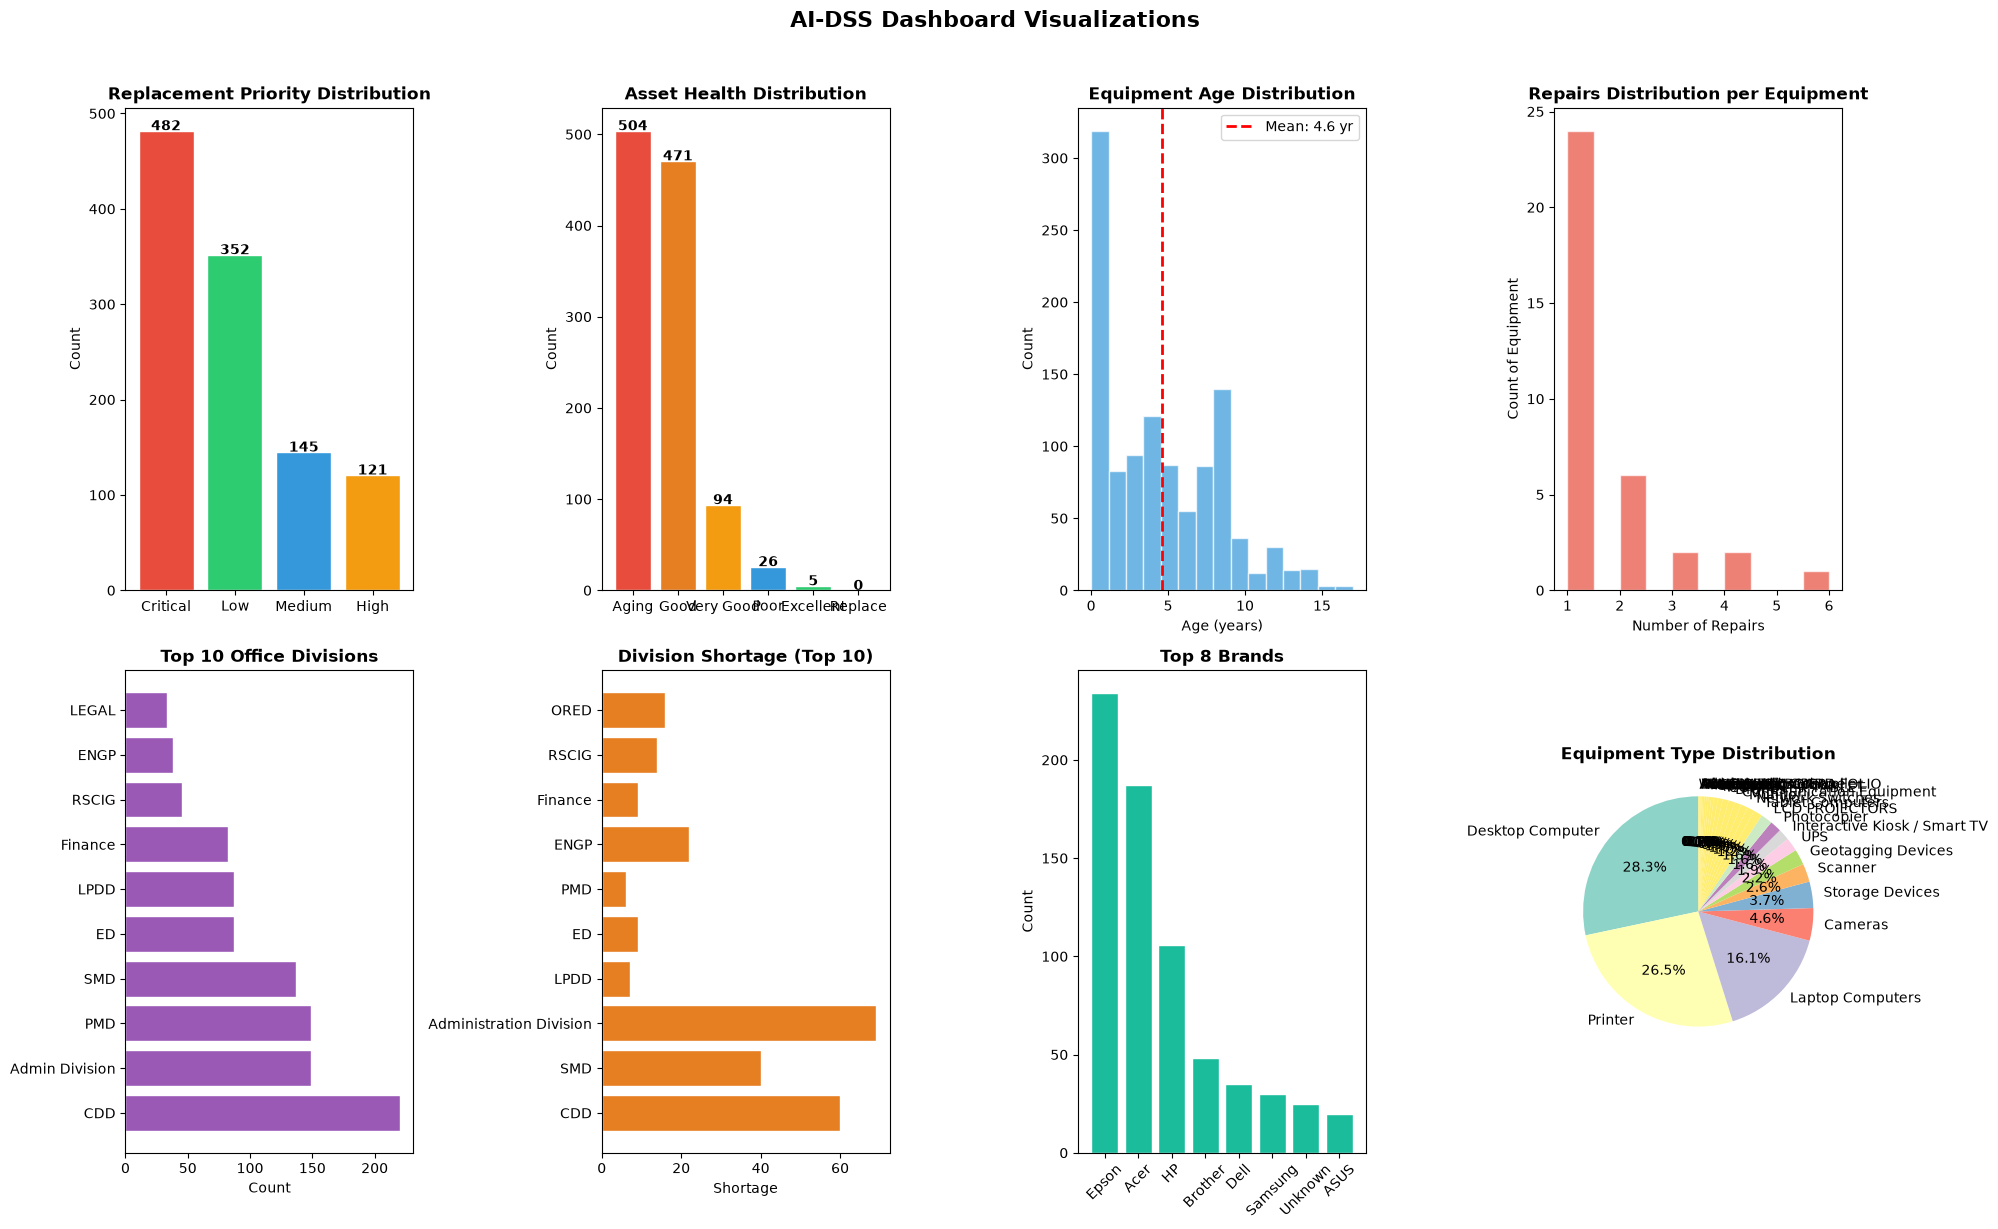

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(20, 12))
fig.suptitle('ICT-AMSOS Dashboard Visualizations', fontsize=16, fontweight='bold', y=1.02)

# --- 1. Replacement Priority Distribution ---
if repl_df is not None and 'predicted_priority' in repl_df.columns:
    priority_counts = repl_df['predicted_priority'].value_counts()
    colors = ['#e74c3c' if p == 'Critical' else '#f39c12' if p == 'High'
              else '#3498db' if p == 'Medium' else '#2ecc71'
              for p in priority_counts.index]
    axes[0, 0].bar(priority_counts.index, priority_counts.values, color=colors, edgecolor='white')
    axes[0, 0].set_title('Replacement Priority Distribution', fontweight='bold')
    axes[0, 0].set_ylabel('Count')
    for i, v in enumerate(priority_counts.values):
        axes[0, 0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# --- 2. Asset Health Distribution ---
if repl_df is not None and 'asset_health_score' in repl_df.columns:
    health = repl_df['asset_health_score']
    bins = [0, 20, 40, 60, 80, 90, 100]
    labels = ['Replace', 'Poor', 'Aging', 'Good', 'Very Good', 'Excellent']
    health_cats = pd.cut(health, bins=bins, labels=labels, right=False)
    health_counts = health_cats.value_counts()
    colors_h = ['#e74c3c', '#e67e22', '#f39c12', '#3498db', '#2ecc71']
    axes[0, 1].bar(health_counts.index, health_counts.values, color=colors_h, edgecolor='white')
    axes[0, 1].set_title('Asset Health Distribution', fontweight='bold')
    axes[0, 1].set_ylabel('Count')
    for i, v in enumerate(health_counts.values):
        axes[0, 1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# --- 3. Equipment Age Distribution ---
inv['yearAcquired'] = pd.to_numeric(inv['yearAcquired'], errors='coerce')
inv['equipment_age'] = CURRENT_YEAR - inv['yearAcquired']
ages = inv['equipment_age'].dropna()
axes[0, 2].hist(ages, bins=15, color='#3498db', edgecolor='white', alpha=0.7)
axes[0, 2].axvline(ages.mean(), color='red', linestyle='--', lw=2, label=f'Mean: {ages.mean():.1f} yr')
axes[0, 2].set_title('Equipment Age Distribution', fontweight='bold')
axes[0, 2].set_xlabel('Age (years)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend()

# --- 4. Repairs Distribution ---
repairs_per_equip = repair.groupby('Equiment ID').size()
axes[0, 3].hist(repairs_per_equip, bins=10, color='#e74c3c', edgecolor='white', alpha=0.7)
axes[0, 3].set_title('Repairs Distribution per Equipment', fontweight='bold')
axes[0, 3].set_xlabel('Number of Repairs')
axes[0, 3].set_ylabel('Count of Equipment')

# --- 5. Office Division Distribution ---
div_counts = inv['officeDivision'].fillna('Unknown').value_counts().head(10)
axes[1, 0].barh(div_counts.index, div_counts.values, color='#9b59b6', edgecolor='white')
axes[1, 0].set_title('Top 10 Office Divisions', fontweight='bold')
axes[1, 0].set_xlabel('Count')

# --- 6. Division Shortage ---
short_div = div_shortage.head(10)
axes[1, 1].barh(short_div['Division'], short_div['shortage'], color='#e67e22', edgecolor='white')
axes[1, 1].set_title('Division Shortage (Top 10)', fontweight='bold')
axes[1, 1].set_xlabel('Shortage')

# --- 7. Brand Distribution ---
brand_clean = inv['brand'].fillna('Unknown').str.strip().replace(['', 'N/A', '0'], 'Unknown')
brand_counts = brand_clean.value_counts().head(8)
axes[1, 2].bar(brand_counts.index, brand_counts.values, color='#1abc9c', edgecolor='white')
axes[1, 2].set_title('Top 8 Brands', fontweight='bold')
axes[1, 2].set_ylabel('Count')
axes[1, 2].tick_params(axis='x', rotation=45)

# --- 8. Equipment Type Distribution ---
type_counts = inv['equipmentType'].value_counts()
axes[1, 3].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
               startangle=90, colors=plt.cm.Set3(range(len(type_counts))))
axes[1, 3].set_title('Equipment Type Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dashboard_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Procurement Budget Visualization

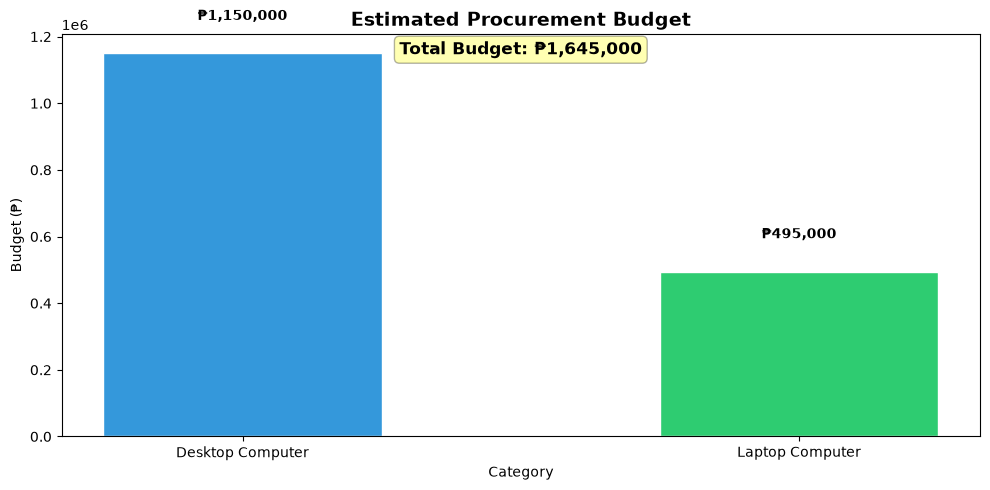

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
budget_data = procurement[procurement['category'] != 'TOTAL']
bars = ax.bar(budget_data['category'], budget_data['estimated_budget'],
              color=['#3498db', '#2ecc71'], edgecolor='white', width=0.5)
ax.set_title('Estimated Procurement Budget', fontsize=14, fontweight='bold')
ax.set_ylabel('Budget (₱)')
ax.set_xlabel('Category')
total = procurement[procurement['category'] == 'TOTAL']['estimated_budget'].values[0]
for bar, val in zip(bars, budget_data['estimated_budget']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100000,
            f'₱{val:,}', ha='center', fontweight='bold')
ax.text(0.5, 0.95, f'Total Budget: ₱{total:,}', transform=ax.transAxes,
        ha='center', fontsize=12, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'procurement_budget.png', dpi=150)
plt.show()

### 6.3 Employee Without Computer - Work Nature Breakdown

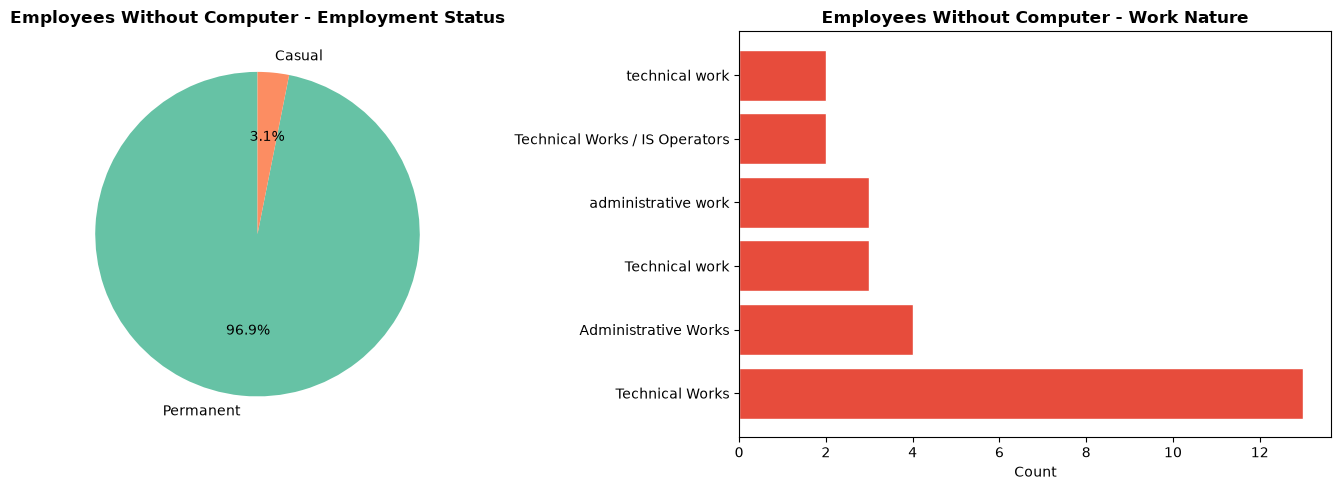

In [15]:
if not emp_priority.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # By status of employment
    status_counts = emp_priority['status_of_employment'].value_counts()
    axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
                startangle=90, colors=plt.cm.Set2(range(len(status_counts))))
    axes[0].set_title('Employees Without Computer - Employment Status', fontweight='bold')

    # By nature of work
    nature_counts = emp_priority['nature_of_work'].value_counts().head(6)
    axes[1].barh(nature_counts.index, nature_counts.values, color='#e74c3c', edgecolor='white')
    axes[1].set_title('Employees Without Computer - Work Nature', fontweight='bold')
    axes[1].set_xlabel('Count')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'employee_priority_analysis.png', dpi=150)
    plt.show()
else:
    print('No employees without computers found.')

---
## Step 7: Final Dashboard Summary

In [16]:
print('=' * 70)
print('COMPREHENSIVE ICT-AMSOS DASHBOARD SUMMARY')
print('=' * 70)

print('\n📊 KEY PERFORMANCE INDICATORS')
print('-' * 40)
for k, v in kpis.items():
    print(f'  {k.replace("_", " ").title():35s}: {v}')

print('\n👥 EMPLOYEE PROCUREMENT PRIORITY')
print('-' * 40)
if not emp_priority.empty:
    desktop_recs = len(emp_priority[emp_priority['recommendation'].str.contains('Desktop', na=False)])
    laptop_recs = len(emp_priority[emp_priority['recommendation'].str.contains('Laptop', na=False)])
    no_proc = len(emp_priority[emp_priority['recommendation'].str.contains('No Procurement', na=False)])
    print(f'  Employees without computer:       {len(emp_priority)}')
    print(f'  Need Desktop:                     {desktop_recs}')
    print(f'  Need Laptop:                      {laptop_recs}')
    print(f'  No procurement needed:            {no_proc}')
else:
    print('  All employees have assigned computers.')

print('\n🏢 DIVISION SHORTAGE')
print('-' * 40)
total_short = int(div_shortage['shortage'].sum())
total_repl = int(div_shortage['replacement_count'].sum())
print(f'  Total shortage across divisions:    {total_short}')
print(f'  Total replacement needed:           {total_repl}')
print(f'  Total units to procure:             {total_short + total_repl}')

print('\n💰 PROCUREMENT BUDGET')
print('-' * 40)
for _, row in procurement.iterrows():
    print(f'  {row["category"]:35s}: {row["recommended_purchase"]:3d} units  ₱{row["estimated_budget"]:>12,}')

print('\n✅ All reports exported to:')
print(f'  {OUTPUT_DIR / "replacement_priority.csv"}')
print(f'  {OUTPUT_DIR / "employee_priority.csv"}')
print(f'  {OUTPUT_DIR / "division_shortage.csv"}')
print(f'  {OUTPUT_DIR / "procurement_recommendation.csv"}')

COMPREHENSIVE ICT-AMSOS DASHBOARD SUMMARY

📊 KEY PERFORMANCE INDICATORS
----------------------------------------
  Total Assets                       : 1100
  Total Computers                    : 467
  Assets Beyond 5Yr                  : 394
  Assets Beyond Useful Life          : 323
  Total Repair Requests              : 56
  Avg Asset Health                   : 62.29
  Critical Assets                    : 482
  High Priority Assets               : 121

👥 EMPLOYEE PROCUREMENT PRIORITY
----------------------------------------
  Employees without computer:       32
  Need Desktop:                     32
  Need Laptop:                      1
  No procurement needed:            0

🏢 DIVISION SHORTAGE
----------------------------------------
  Total shortage across divisions:    260
  Total replacement needed:           154
  Total units to procure:             414

💰 PROCUREMENT BUDGET
----------------------------------------
  Desktop Computer                   :  23 units  ₱   1,150,00

---
## Summary

Notebook 04 completed:
- ✅ Computed 8+ KPIs (Total Assets, Computers, Beyond Life, Health, etc.)
- ✅ Identified and ranked employees without computers
- ✅ Analyzed division-level computer shortages
- ✅ Generated procurement recommendations with budget estimates
- ✅ 10+ visualizations saved to `outputs/`
- ✅ 4 CSV reports exported
- ✅ Full ICT-AMSOS decision support ready